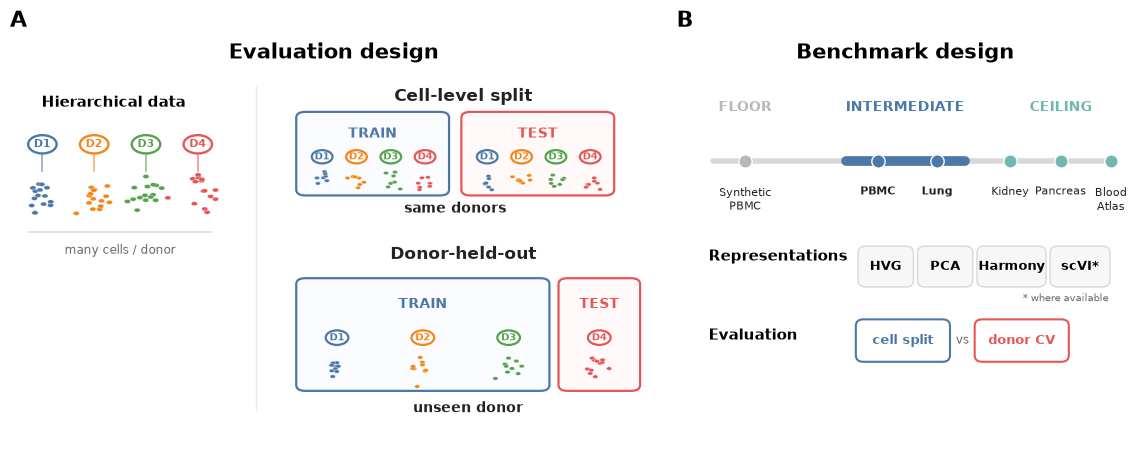

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle

np.random.seed(7)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

DONOR = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
]

TRAIN = "#4C78A8"
TEST = "#E45756"

DARK = "#222222"
MID = "#6B6B6B"
LIGHT = "#D8D8D8"
PALE = "#F7F7F7"

FLOOR = "#B8B8B8"
INTERMEDIATE = "#4C78A8"
CEILING = "#72B7B2"


# ============================================================
# Helpers
# ============================================================

def setup(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")


def rounded_box(
    ax,
    x,
    y,
    w,
    h,
    edgecolor=DARK,
    facecolor="white",
    lw=1.5,
    radius=0.02,
    zorder=1,
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=f"round,pad=0.008,rounding_size={radius}",
        edgecolor=edgecolor,
        facecolor=facecolor,
        linewidth=lw,
        zorder=zorder,
    )
    ax.add_patch(patch)
    return patch


def donor_badge(
    ax,
    x,
    y,
    donor_idx,
    r=0.022,
    lw=1.6,
    fontsize=7.2,
):
    ax.add_patch(
        Circle(
            (x, y),
            r,
            facecolor="white",
            edgecolor=DONOR[donor_idx],
            linewidth=lw,
            zorder=5,
        )
    )

    ax.text(
        x,
        y,
        f"D{donor_idx + 1}",
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
        color=DONOR[donor_idx],
        zorder=6,
    )


def cloud(
    ax,
    center,
    n=12,
    spread=(0.018, 0.022),
    color="#777777",
    radius=0.0047,
    seed=0,
):
    rng = np.random.default_rng(seed)

    xs = rng.normal(
        center[0],
        spread[0],
        n,
    )

    ys = rng.normal(
        center[1],
        spread[1],
        n,
    )

    for x, y in zip(xs, ys):
        ax.add_patch(
            Circle(
                (x, y),
                radius,
                facecolor=color,
                edgecolor="white",
                linewidth=0.2,
                zorder=4,
            )
        )


# ============================================================
# Canvas
# ============================================================

fig = plt.figure(
    figsize=(14.5, 5.4),
    facecolor="white",
)

gs = fig.add_gridspec(
    1,
    12,
    wspace=0.25,
)

axA = fig.add_subplot(
    gs[0, :7]
)

axB = fig.add_subplot(
    gs[0, 7:]
)

for ax in [axA, axB]:
    setup(ax)


# ============================================================
# PANEL A
# Evaluation design
# ============================================================

axA.text(
    0.0,
    1.01,
    "A",
    fontsize=16,
    fontweight="bold",
    ha="left",
    va="bottom",
)

axA.text(
    0.50,
    0.985,
    "Evaluation design",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="top",
)


# ------------------------------------------------------------
# Hierarchical data
# ------------------------------------------------------------

axA.text(
    0.16,
    0.84,
    "Hierarchical data",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
)

source_x = [
    0.05,
    0.13,
    0.21,
    0.29,
]

for i, x in enumerate(source_x):

    donor_badge(
        axA,
        x,
        0.74,
        i,
        r=0.022,
        lw=1.7,
        fontsize=7.6,
    )

    axA.plot(
        [x, x],
        [0.715, 0.675],
        color=DONOR[i],
        lw=1.2,
        alpha=0.65,
    )

    cloud(
        axA,
        (x, 0.62),
        n=15,
        spread=(0.015, 0.024),
        color=DONOR[i],
        radius=0.0048,
        seed=10 + i,
    )

axA.plot(
    [0.03, 0.31],
    [0.53, 0.53],
    color=LIGHT,
    lw=1.1,
)

axA.text(
    0.17,
    0.485,
    "many cells / donor",
    ha="center",
    va="center",
    fontsize=8.8,
    color=MID,
)


# Divider
axA.plot(
    [0.38, 0.38],
    [0.10, 0.88],
    color="#EAEAEA",
    lw=1.0,
)


# ------------------------------------------------------------
# Cell-level split
# ------------------------------------------------------------

axA.text(
    0.70,
    0.855,
    "Cell-level split",
    ha="center",
    va="center",
    fontsize=12.3,
    fontweight="bold",
    color=DARK,
)

rounded_box(
    axA,
    0.45,
    0.625,
    0.22,
    0.185,
    edgecolor=TRAIN,
    facecolor="#FAFCFF",
    lw=1.6,
    radius=0.014,
)

rounded_box(
    axA,
    0.705,
    0.625,
    0.22,
    0.185,
    edgecolor=TEST,
    facecolor="#FFF9F9",
    lw=1.6,
    radius=0.014,
)

axA.text(
    0.56,
    0.765,
    "TRAIN",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=TRAIN,
)

axA.text(
    0.815,
    0.765,
    "TEST",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=TEST,
)

train_x = [
    0.482,
    0.535,
    0.588,
    0.641,
]

test_x = [
    0.737,
    0.790,
    0.843,
    0.896,
]

for i, (xt, xs) in enumerate(
    zip(train_x, test_x)
):

    donor_badge(
        axA,
        xt,
        0.71,
        i,
        r=0.0160,
        lw=1.6,
        fontsize=7.1,
    )

    donor_badge(
        axA,
        xs,
        0.71,
        i,
        r=0.0160,
        lw=1.6,
        fontsize=7.1,
    )

    cloud(
        axA,
        (xt, 0.652),
        n=7,
        spread=(0.0068, 0.0100),
        color=DONOR[i],
        radius=0.0039,
        seed=100 + i,
    )

    cloud(
        axA,
        (xs, 0.652),
        n=7,
        spread=(0.0068, 0.0100),
        color=DONOR[i],
        radius=0.0039,
        seed=200 + i,
    )

axA.text(
    0.6875,
    0.585,
    "same donors",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=DARK,
)


# ------------------------------------------------------------
# Donor-held-out
# ------------------------------------------------------------

axA.text(
    0.70,
    0.475,
    "Donor-held-out",
    ha="center",
    va="center",
    fontsize=12.3,
    fontweight="bold",
    color=DARK,
)

rounded_box(
    axA,
    0.45,
    0.155,
    0.375,
    0.255,
    edgecolor=TRAIN,
    facecolor="#FAFCFF",
    lw=1.6,
    radius=0.014,
)

rounded_box(
    axA,
    0.855,
    0.155,
    0.11,
    0.255,
    edgecolor=TEST,
    facecolor="#FFF9F9",
    lw=1.6,
    radius=0.014,
)

axA.text(
    0.6375,
    0.355,
    "TRAIN",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=TRAIN,
)

axA.text(
    0.91,
    0.355,
    "TEST",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=TEST,
)

held_train_x = [
    0.505,
    0.6375,
    0.77,
]

for i, x in enumerate(
    held_train_x
):

    donor_badge(
        axA,
        x,
        0.275,
        i,
        r=0.0175,
        lw=1.6,
        fontsize=7.3,
    )

    cloud(
        axA,
        (x, 0.205),
        n=9,
        spread=(0.0085, 0.0135),
        color=DONOR[i],
        radius=0.0041,
        seed=300 + i,
    )

donor_badge(
    axA,
    0.91,
    0.275,
    3,
    r=0.0175,
    lw=1.6,
    fontsize=7.3,
)

cloud(
    axA,
    (0.91, 0.205),
    n=11,
    spread=(0.009, 0.014),
    color=DONOR[3],
    radius=0.0041,
    seed=400,
)

axA.text(
    0.7075,
    0.105,
    "unseen donor",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=DARK,
)


# ============================================================
# PANEL B
# Benchmark design
# ============================================================

axB.text(
    0.0,
    1.01,
    "B",
    fontsize=16,
    fontweight="bold",
    ha="left",
    va="bottom",
)

axB.text(
    0.50,
    0.985,
    "Benchmark design",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="top",
)


# ------------------------------------------------------------
# Benchmark regimes
# ------------------------------------------------------------

y = 0.70

axB.plot(
    [0.08, 0.95],
    [y, y],
    color=LIGHT,
    lw=4,
    solid_capstyle="round",
    zorder=1,
)

axB.plot(
    [0.37, 0.63],
    [y, y],
    color=INTERMEDIATE,
    lw=7,
    solid_capstyle="round",
    zorder=2,
)

axB.text(
    0.15,
    0.82,
    "FLOOR",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color=FLOOR,
)

axB.text(
    0.50,
    0.82,
    "INTERMEDIATE",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color=INTERMEDIATE,
)

axB.text(
    0.84,
    0.82,
    "CEILING",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color=CEILING,
)

datasets = [
    (0.15, "Synthetic\nPBMC", FLOOR),
    (0.44, "PBMC", INTERMEDIATE),
    (0.57, "Lung", INTERMEDIATE),
    (0.73, "Kidney", CEILING),
    (0.84, "Pancreas", CEILING),
    (0.95, "Blood\nAtlas", CEILING),
]

for x, label, color in datasets:

    axB.scatter(
        [x],
        [y],
        s=92,
        color=color,
        edgecolor="white",
        linewidth=1.0,
        zorder=4,
    )

    axB.text(
        x,
        y - 0.06,
        label,
        ha="center",
        va="top",
        fontsize=8.1,
        fontweight=(
            "bold"
            if color == INTERMEDIATE
            else "normal"
        ),
        color=DARK,
    )


# ------------------------------------------------------------
# Representations
# ------------------------------------------------------------

axB.text(
    0.07,
    0.47,
    "Representations",
    ha="left",
    va="center",
    fontsize=11,
    fontweight="bold",
)

rep_specs = [
    ("HVG",     0.405, 0.105),
    ("PCA",     0.535, 0.105),
    ("Harmony", 0.665, 0.135),
    ("scVI*",   0.825, 0.115),
]

for name, x, w in rep_specs:

    rounded_box(
        axB,
        x,
        0.405,
        w,
        0.082,
        edgecolor=LIGHT,
        facecolor=PALE,
        lw=1.0,
        radius=0.016,
    )

    axB.text(
        x + w / 2,
        0.446,
        name,
        ha="center",
        va="center",
        fontsize=9.2,
        fontweight="bold",
    )

axB.text(
    0.945,
    0.382,
    "* where available",
    ha="right",
    va="top",
    fontsize=7.1,
    color=MID,
)


# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

axB.text(
    0.07,
    0.28,
    "Evaluation",
    ha="left",
    va="center",
    fontsize=11,
    fontweight="bold",
)

rounded_box(
    axB,
    0.40,
    0.225,
    0.19,
    0.086,
    edgecolor=TRAIN,
    facecolor="white",
    lw=1.5,
    radius=0.016,
)

axB.text(
    0.495,
    0.268,
    "cell split",
    ha="center",
    va="center",
    fontsize=9.4,
    fontweight="bold",
    color=TRAIN,
)

axB.text(
    0.625,
    0.268,
    "vs",
    ha="center",
    va="center",
    fontsize=8.5,
    color=MID,
)

rounded_box(
    axB,
    0.66,
    0.225,
    0.19,
    0.086,
    edgecolor=TEST,
    facecolor="white",
    lw=1.5,
    radius=0.016,
)

axB.text(
    0.755,
    0.268,
    "donor CV",
    ha="center",
    va="center",
    fontsize=9.4,
    fontweight="bold",
    color=TEST,
)


# ============================================================
# Save
# ============================================================

#plt.savefig(
    #"figure1_motivation.png",
    #dpi=400,
    #bbox_inches="tight",
#)

#plt.savefig(
    #"figure1_motivation.pdf",
    #bbox_inches="tight",
#)

plt.show()